
# MODULE 3: IMAGE CLASSIFICATION

Christian Mata, PhD


# **EXERCISE 4**

Connecting to Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#1. Generate synthetic image with random blobs

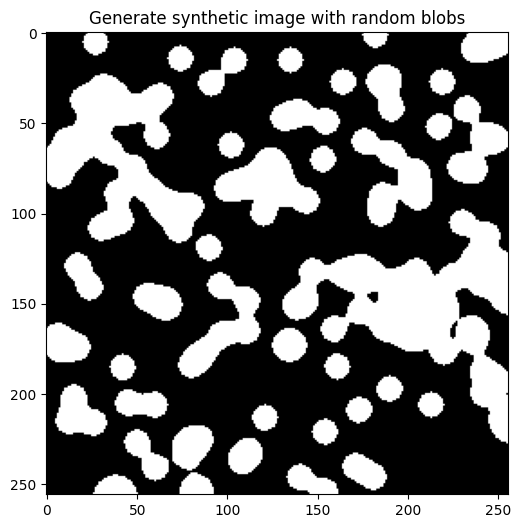

In [4]:
import matplotlib.pyplot as plt
from skimage.data import binary_blobs

# Generate synthetic image with random blobs
image = binary_blobs(length=256,blob_size_fraction=0.08,volume_fraction=0.35)

# Show image
plt.figure(figsize=(6,6))

plt.imshow(image, cmap='gray')
plt.title('Generate synthetic image with random blobs')

plt.show()

# 2. Object segmentation and labeling

- Segmentation of blobs using Otsu's optimal threshold
- Labeling connected regions
- Visualization



/usr/local/lib/python3.12/dist-packages/skimage/exposure/exposure.py:306: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bin_edges = np.histogram(image, bins=bins, range=hist_range)


Number of regions: 40


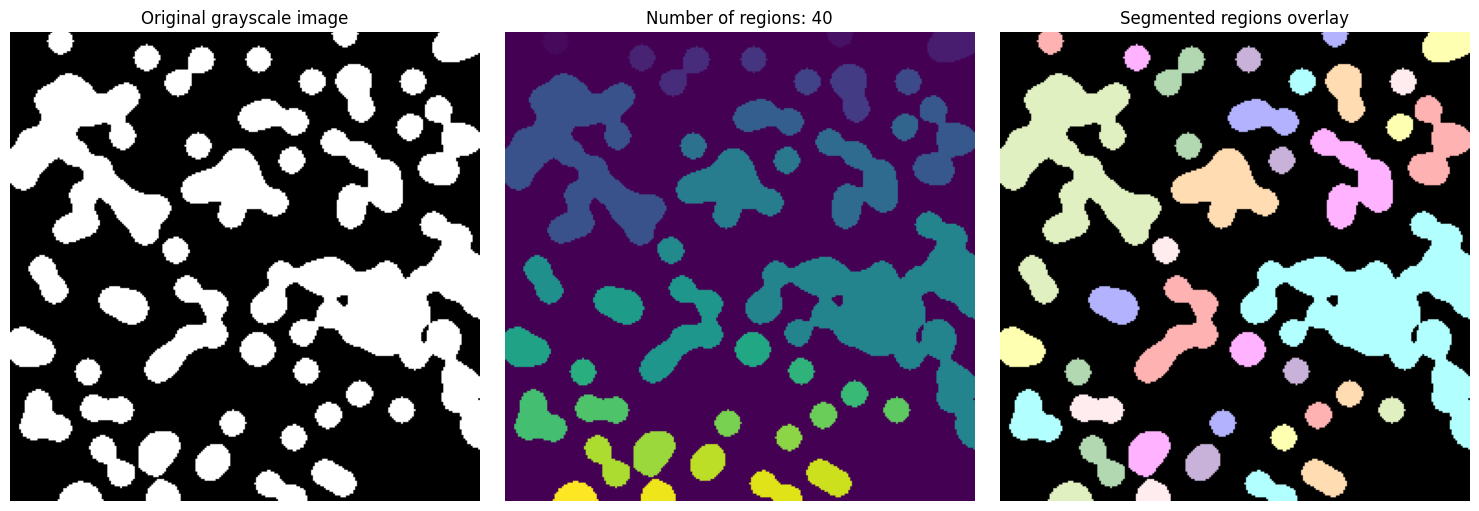

In [5]:
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.color import label2rgb

# Otsu threshold
thresh = threshold_otsu(image)
bw = image > thresh

# Label connected regions
label_image, nregions = label(bw, return_num=True)

# Overlay labelled regions on original image
image_label_overlay = label2rgb(label_image, image=image)

print("Number of regions:", nregions)

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax = ax.ravel()

images = [image, label_image, image_label_overlay]
titles = ['Original grayscale image', f'Number of regions: {nregions}', 'Segmented regions overlay']

for i in range(3):
    ax[i].imshow(images[i], cmap='gray' if i == 0 else None)
    ax[i].set_title(titles[i])
    ax[i].axis('off')

plt.tight_layout()
plt.show()

# 3. Get regional properties in a pandas dataframe

Function documentation with a list of available attributes can be found at https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops_table


In [9]:
import pandas as pd
from skimage.measure import regionprops_table

# Extract regional properties into a dataframe
props_table = regionprops_table(
    label_image,
    properties=['label', 'area', 'eccentricity', 'centroid', 'axis_major_length',]
)

# Convert to pandas dataframe
df = pd.DataFrame(props_table)
df.head(10)

,label,area,eccentricity,centroid-0,centroid-1,axis_major_length
0,1,144.0,0.347613,5.472222,27.034722,14.020823
1,2,98.0,0.762121,3.265306,182.051020,14.188274
2,3,388.0,0.773164,7.518041,242.613402,28.104800
3,4,155.0,0.050959,14.154839,74.090323,14.070789
4,5,343.0,0.927741,21.545190,97.384840,37.290034
5,6,149.0,0.000000,15.000000,135.000000,13.778692
6,7,470.0,0.843441,32.259574,188.389362,34.272493
7,8,158.0,0.224744,27.120253,164.208861,14.383560
8,9,158.0,0.132712,27.183544,219.183544,14.257503
9,10,3918.0,0.720071,68.920368,41.187851,107.403223


Represent area of the blobs as a function of the major axis length

<Figure size 700x500 with 0 Axes>

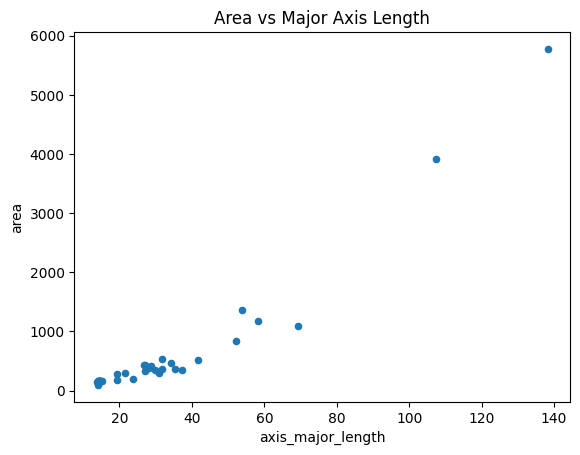

In [10]:
# Scatter plot: area as a function of major axis length
plt.figure(figsize=(7, 5))

df.plot.scatter(x='axis_major_length', y='area')

plt.xlabel('axis_major_length')
plt.ylabel('area')
plt.title('Area vs Major Axis Length')

plt.show()

Clear correlation between blob's length and area can be observed

#4. Analyze blobs


Since you have the feature data in a pandas dataframe, you can exploit all the functions of te libraries. For instance:

How many blobs have an area above the average?

In [13]:
# Compute average area
average_area = df['area'].mean()

# Count blobs with area above average
n_large_blobs = (df['area'] > average_area).sum()

print("Average area:", average_area)
print("Number of blobs with area above the average:", n_large_blobs)

# Show blobs with area above average
large_blobs = df[df['area'] > average_area]

large_blobs[['label', 'area', 'eccentricity', 'axis_major_length']]

Average area: 573.45
Number of blobs with area above the average: 6


,label,area,eccentricity,axis_major_length
9,10,3918.0,0.720071,107.403223
10,11,842.0,0.807700,52.063469
13,14,1182.0,0.713664,58.226358
16,17,1357.0,0.725265,53.891059
17,18,5777.0,0.730260,138.289549
20,21,1093.0,0.872614,69.399724


Represent the blobs that have an area smaller than the average blob's area

In [15]:
# Show blobs with area smaller than the average area
average_area = df['area'].mean()

small_blobs = df[df['area'] < average_area]
n_small_blobs = (df['area'] < average_area).sum()

print("Number of blobs with area below the average:", n_small_blobs)

small_blobs[['label','area','eccentricity','axis_major_length']]

Number of blobs with area below the average: 34


,label,area,eccentricity,axis_major_length
0,1,144.0,0.347613,14.020823
1,2,98.0,0.762121,14.188274
2,3,388.0,0.773164,28.104800
3,4,155.0,0.050959,14.070789
4,5,343.0,0.927741,37.290034
5,6,149.0,0.000000,13.778692
6,7,470.0,0.843441,34.272493
7,8,158.0,0.224744,14.383560
8,9,158.0,0.132712,14.257503
11,12,513.0,0.910644,41.566714


find the labels of small and large blobs

In [16]:
# Find labels of small and large blobs
average_area = df['area'].mean()

large_blobs = df[df['area'] >= average_area]
print("Labels of large blobs:")
print(large_blobs['label'].values)

small_blobs = df[df['area'] < average_area]
print("\nLabels of small blobs:")
print(small_blobs['label'].values)

Labels of large blobs:
[10 11 14 17 18 21]

Labels of small blobs:
[ 1  2  3  4  5  6  7  8  9 12 13 15 16 19 20 22 23 24 25 26 27 28 29 30
 31 32 33 34 35 36 37 38 39 40]


Create a binary mask with the large and small blobs

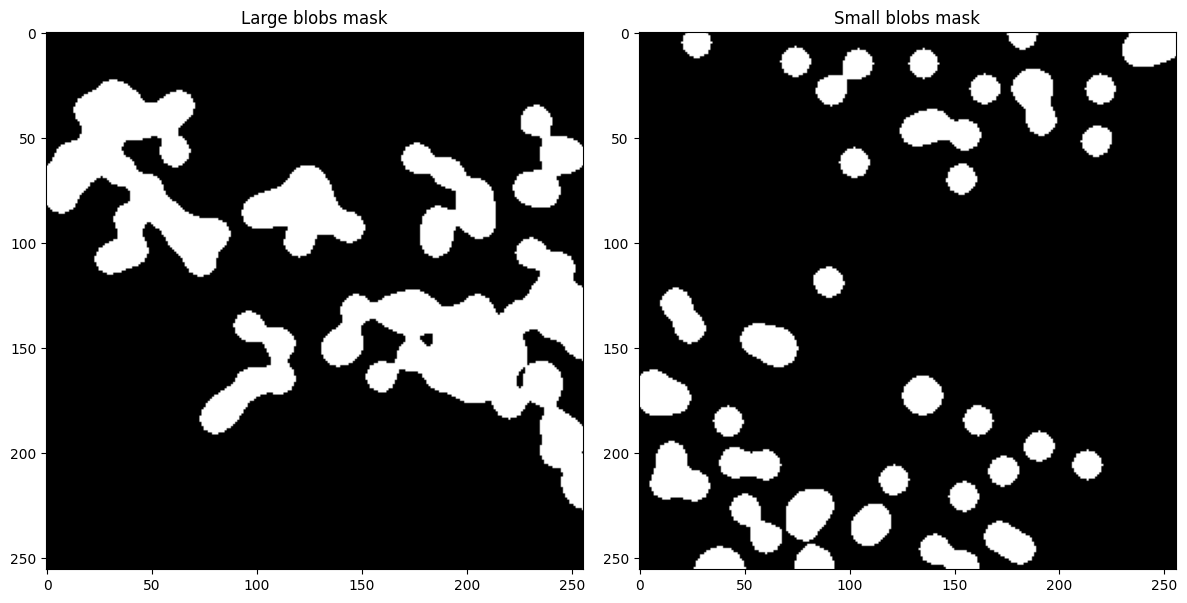

In [17]:
# Create binary mask for large blobs
mask_large = np.isin(label_image, large_blobs['label'])

# Create binary mask for small blobs
mask_small = np.isin(label_image, small_blobs['label'])

# Show masks
fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].imshow(mask_large, cmap='gray')
ax[0].set_title('Large blobs mask')

ax[1].imshow(mask_small, cmap='gray')
ax[1].set_title('Small blobs mask')

plt.tight_layout()
plt.show()

#5. Obtain texture-based regional properties

For the original image

In [20]:
from skimage.feature.texture import graycomatrix

# Convert image to uint8
image_uint8 = (image * 255).astype(np.uint8)

# Compute GLCM
g = graycomatrix(image_uint8,
                 distances=[1],
                 angles=[0],
                 levels=256,
                 normed=False,
                 symmetric=False)

print('Number of times that a grayscale level zero has a neighbour with value zero at a distance of 1 pixel to the right (angle equal zero): {}'
      .format(g[0,0,0,0]))

print('Number of times that a grayscale level zero has a neighbour with value 1 at a distance of 1 pixel to the right (angle equal zero): {}'
      .format(g[0,1,0,0]))

print('Number of times that a grayscale level 2 has a neighbour with value 2 at a distance of 1 pixel to the right (angle equal zero): {}'
      .format(g[2,2,0,0]))

print('Number of times that a grayscale level 2 has a neighbour with value 0 at a distance of 1 pixel to the right (angle equal zero): {}'
      .format(g[2,0,0,0]))

Number of times that a grayscale level zero has a neighbour with value zero at a distance of 1 pixel to the right (angle equal zero): 41241
Number of times that a grayscale level zero has a neighbour with value 1 at a distance of 1 pixel to the right (angle equal zero): 0
Number of times that a grayscale level 2 has a neighbour with value 2 at a distance of 1 pixel to the right (angle equal zero): 0
Number of times that a grayscale level 2 has a neighbour with value 0 at a distance of 1 pixel to the right (angle equal zero): 0


In [21]:
import pandas as pd
from skimage.feature.texture import graycomatrix, graycoprops
from skimage.measure import regionprops

props = regionprops(label_image)

texture_features = []

for p in props:

    minr, minc, maxr, maxc = p.bbox

    # Extract region
    region = image[minr:maxr, minc:maxc]

    # Convert to uint8
    region_uint8 = (region * 255).astype(np.uint8)

    # Compute GLCM
    g = graycomatrix(region_uint8,
                     distances=[1],
                     angles=[0],
                     levels=256,
                     normed=True,
                     symmetric=True)

    # Texture properties
    contrast = graycoprops(g, 'contrast')[0,0]
    dissimilarity = graycoprops(g, 'dissimilarity')[0,0]
    homogeneity = graycoprops(g, 'homogeneity')[0,0]
    energy = graycoprops(g, 'energy')[0,0]
    correlation = graycoprops(g, 'correlation')[0,0]

    texture_features.append([
        contrast,
        dissimilarity,
        homogeneity,
        energy,
        correlation
    ])

# Create dataframe
df_texture = pd.DataFrame(texture_features,
                          columns=['Contrast',
                                   'Dissimilarity',
                                   'Homogeneity',
                                   'Energy',
                                   'Correlation'])

# Show first 10 rows
df_texture.head(10)

,Contrast,Dissimilarity,Homogeneity,Energy,Correlation
0,8574.725275,33.626374,0.868134,0.740801,0.608392
1,8257.142857,32.380952,0.873018,0.731279,0.641664
2,2448.000000,9.600000,0.962354,0.877912,0.804979
3,8050.714286,31.571429,0.876192,0.704279,0.686963
4,4472.619048,17.539683,0.931218,0.663881,0.861103
5,8670.000000,34.000000,0.866669,0.684324,0.679599
6,5612.276786,22.008929,0.913692,0.705084,0.796438
7,7431.428571,29.142857,0.885716,0.715649,0.704399
8,8050.714286,31.571429,0.876192,0.713778,0.675926
9,2456.924065,9.634996,0.962216,0.681366,0.924338
